# Corner Plot

In [1]:

import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import torch 
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
from galaxy_generation import transform_params
from object_handler import load_csv
import corner

In [4]:
# cored_params = load_csv("./model_7_1/5d/mass_density_samples_core.csv", "ndarray")
cusp_params = load_csv("./model_8/mock/MockA_samples.csv", "ndarray")
log_rs = cusp_params[:, 4]
rstar_div_rs = cusp_params[:, 5]
ra_div_rstar = cusp_params[:, 6]
rstar = log_rs + rstar_div_rs
ra = ra_div_rstar + rstar

cusp_params[:, 5] = rstar
cusp_params[:, 6] = ra



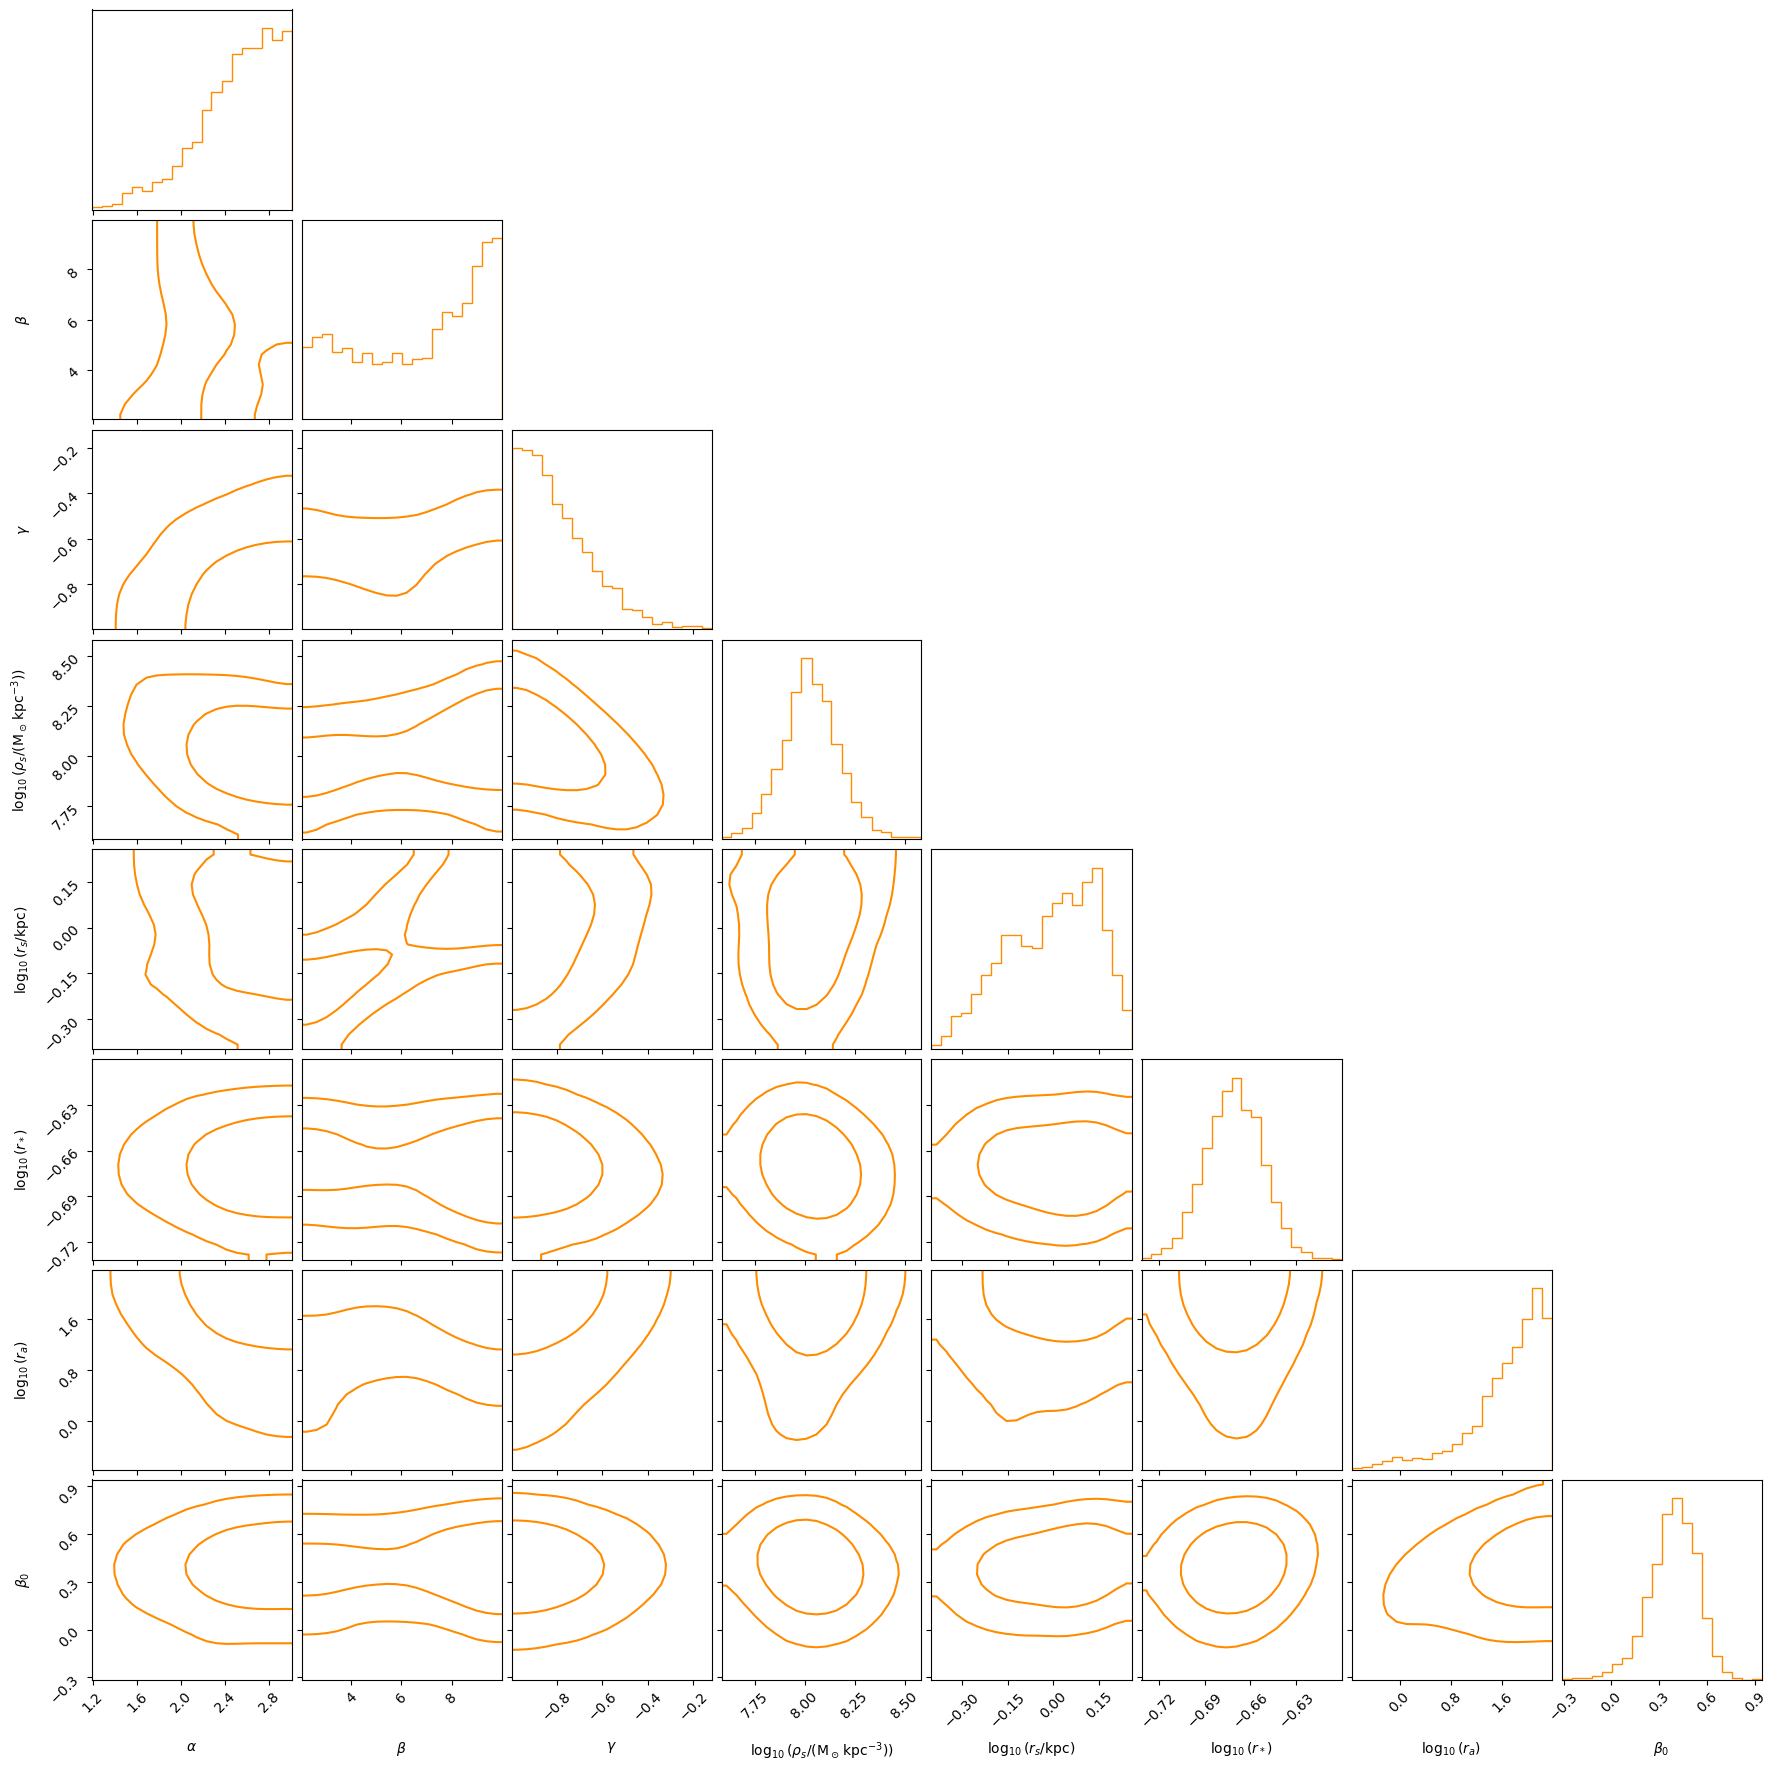

In [6]:
labels = [
    r"$\alpha$",
    r"$\beta$",
    r"$\gamma$",
    r"$\log_{10}(\rho_s / (\mathrm{M}_\odot\,\mathrm{kpc}^{-3}))$",
    r"$\log_{10}(r_s / \mathrm{kpc})$",
    r"$\log_{10}(r_* )$",
    r"$\log_{10}(r_a )$",
    r"$\beta_0$"
]

fig = corner.corner(
    cusp_params,
    labels=labels,
    color="darkorange",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=False,
    no_fill_contours=True,
    levels=(0.68, 0.95), # Confidence intervals to plot
    # truths=[1, 3, 1, 8.0755, 0, -0.6402, 0, 0],
    # bins=30,
    smooth=2,
    # smooth1d=1.0,
)